In [37]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('weight-height.csv')

In [39]:
df.shape

(10000, 3)

In [40]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [41]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

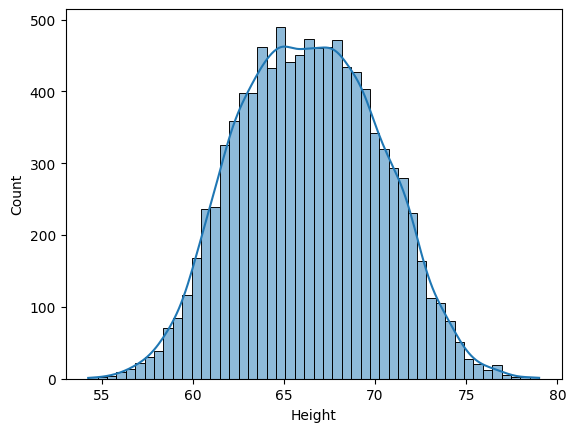

In [42]:
sns.histplot(df['Height'] , kde=True)
plt.show()

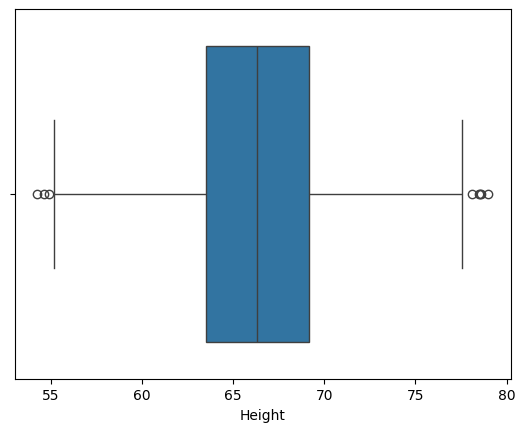

In [43]:
sns.boxplot(x=df['Height'])
plt.show()

In [44]:
upper_lim = df['Height'].quantile(0.99)
lower_lim =  df['Height'].quantile(0.01)

In [45]:
upper_lim

np.float64(74.7857900583366)

In [46]:
lower_lim

np.float64(58.13441158671655)

In [47]:
# Detecting Outlier

df[(df['Height'] >= 74.78) | (df['Height'] <= 58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# **Trimming Outlier**

In [48]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [49]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

In [50]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

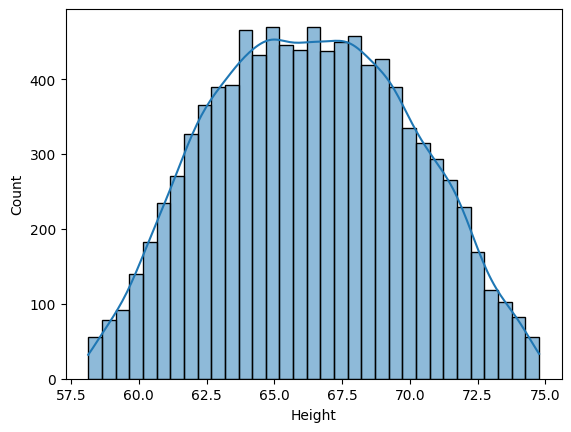

In [51]:
sns.histplot(new_df['Height'] , kde=True)
plt.show()

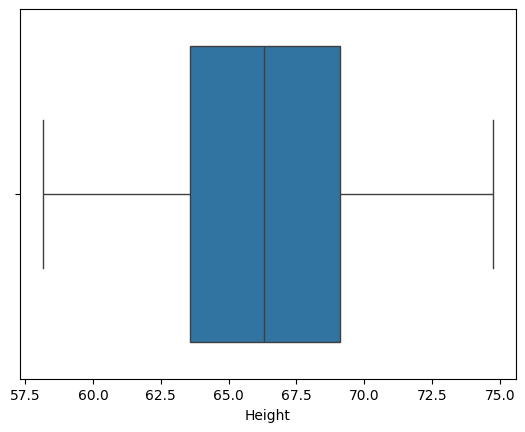

In [ ]:
sns.boxplot(x = new_df['Height'])
plt.show()

# **Capping / Winsorizaion**

In [ ]:
Cap_df = df.copy()
Cap_df['Height'] = np.where(Cap_df['Height'] >= upper_lim ,
                            upper_lim ,
                            np.where(
                                Cap_df['Height'] <= lower_lim ,
                                lower_lim ,
                                Cap_df['Height'] 
                            ))

In [56]:
Cap_df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

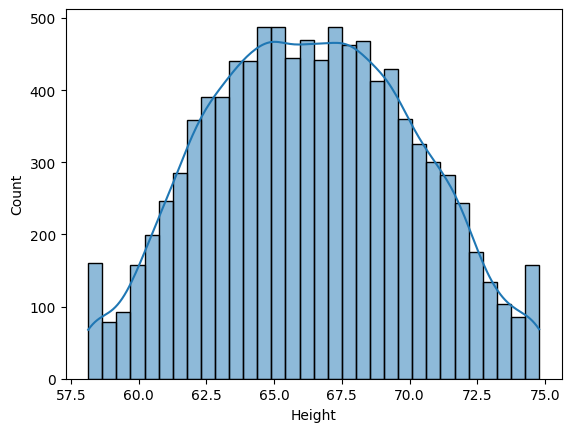

In [57]:
sns.histplot(Cap_df['Height'] , kde=True)
plt.show()

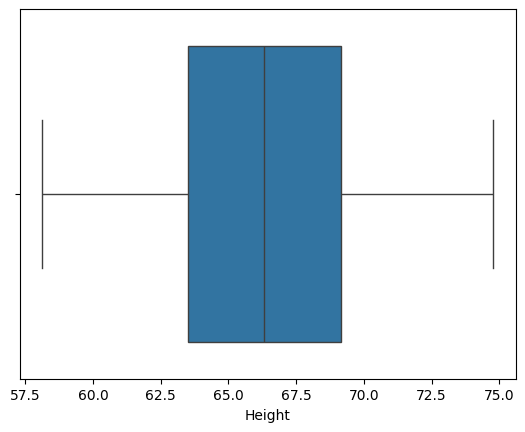

In [58]:
sns.boxplot(x=Cap_df['Height'])
plt.show()